In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from utils.db_utils import get_engine, read_sql


In [2]:
PROFILE_COLUMNS = ["Customer_ID", "Cluster", "Recency", "Frequency", "Monetary", "AOV", "Units_Purchased"]
engine = get_engine()
profiling_df = read_sql(engine, "SELECT customer_id, rfm_segment, days_since_last_purchase, total_orders, total_revenue, average_order_value, total_quantity FROM marts.mart_customer WHERE rfm_segment IS NOT NULL")
engine.dispose()
profiling_df.columns = PROFILE_COLUMNS


In [3]:
data_check = pd.DataFrame({"Metric": ["Dataframe Rows", "Dataframe Columns", "Unique Customers", "Duplicate Customer Rows"], "Value": [profiling_df.shape[0], profiling_df.shape[1], profiling_df["Customer_ID"].nunique(), profiling_df.duplicated("Customer_ID", keep=False).sum()]})
cluster_counts = profiling_df["Cluster"].value_counts().rename_axis("Cluster").reset_index(name="Customer Count")
missing_check = profiling_df[PROFILE_COLUMNS].isna().sum().rename("Missing Values").to_frame()
display(data_check)
display(cluster_counts)
display(missing_check)


,Metric,Value
0,Dataframe Rows,86691
1,Dataframe Columns,7
2,Unique Customers,86691
3,Duplicate Customer Rows,0


,Cluster,Customer Count
0,Mid-Value Customers,32782
1,High-Value Customers,27988
2,Low-Value Customers,25921


,Missing Values
Customer_ID,0
Cluster,0
Recency,0
Frequency,0
Monetary,0
AOV,0
Units_Purchased,0


In [4]:
cluster_summary = profiling_df.groupby("Cluster").agg(**{"Customer Count": ("Customer_ID", "nunique"), "Total Revenue": ("Monetary", "sum"), "Median Recency": ("Recency", "median"), "Median Frequency": ("Frequency", "median"), "Median Monetary": ("Monetary", "median"), "Median AOV": ("AOV", "median")})
cluster_summary["Customer Share %"] = cluster_summary["Customer Count"] / cluster_summary["Customer Count"].sum() * 100
cluster_summary["Revenue Share %"] = cluster_summary["Total Revenue"] / cluster_summary["Total Revenue"].sum() * 100
cluster_summary["Revenue per Customer"] = cluster_summary["Total Revenue"] / cluster_summary["Customer Count"]
cluster_summary = cluster_summary[["Customer Count", "Customer Share %", "Total Revenue", "Revenue Share %", "Revenue per Customer", "Median Recency", "Median Frequency", "Median Monetary", "Median AOV"]].sort_values("Revenue per Customer", ascending=False)
summary_format = {"Customer Count": "{:,.0f}", "Customer Share %": "{:.2f}%", "Total Revenue": "{:,.2f}", "Revenue Share %": "{:.2f}%", "Revenue per Customer": "{:,.2f}", "Median Recency": "{:,.0f}", "Median Frequency": "{:,.0f}", "Median Monetary": "{:,.2f}", "Median AOV": "{:,.2f}"}
display(cluster_summary.style.format(summary_format))


,Customer Count,Customer Share %,Total Revenue,Revenue Share %,Revenue per Customer,Median Recency,Median Frequency,Median Monetary,Median AOV
Cluster,,,,,,,,,
High-Value Customers,"27,988",32.28%,"10,010,684,520.36",74.80%,"357,677.74",303,12,"296,476.45","24,565.16"
Mid-Value Customers,"32,782",37.81%,"2,714,282,815.91",20.28%,"82,797.96","1,003",3,"75,589.94","22,882.77"
Low-Value Customers,"25,921",29.90%,"659,147,336.52",4.92%,"25,429.09","2,502",1,"18,396.91","13,736.09"


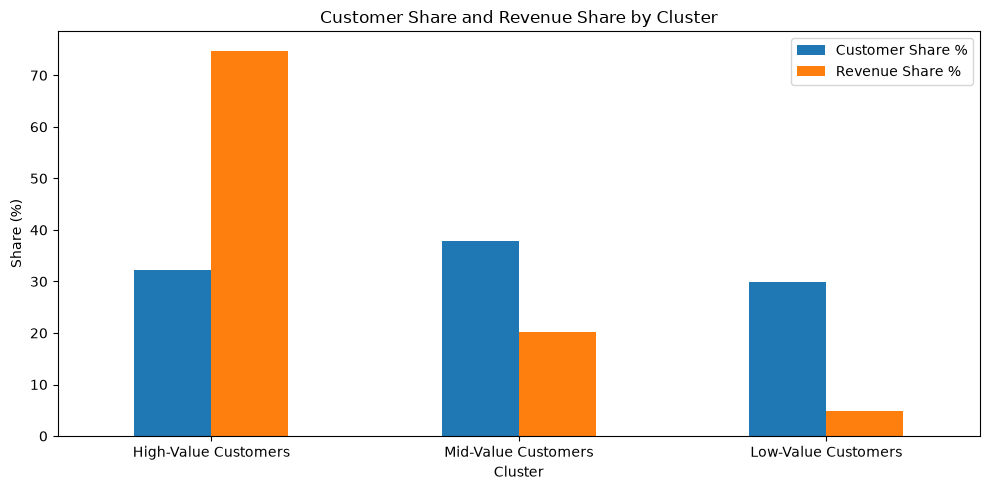

In [5]:
share_chart_data = cluster_summary[["Customer Share %", "Revenue Share %"]]
ax = share_chart_data.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set(title="Customer Share and Revenue Share by Cluster", xlabel="Cluster", ylabel="Share (%)")
plt.tight_layout()
plt.show()


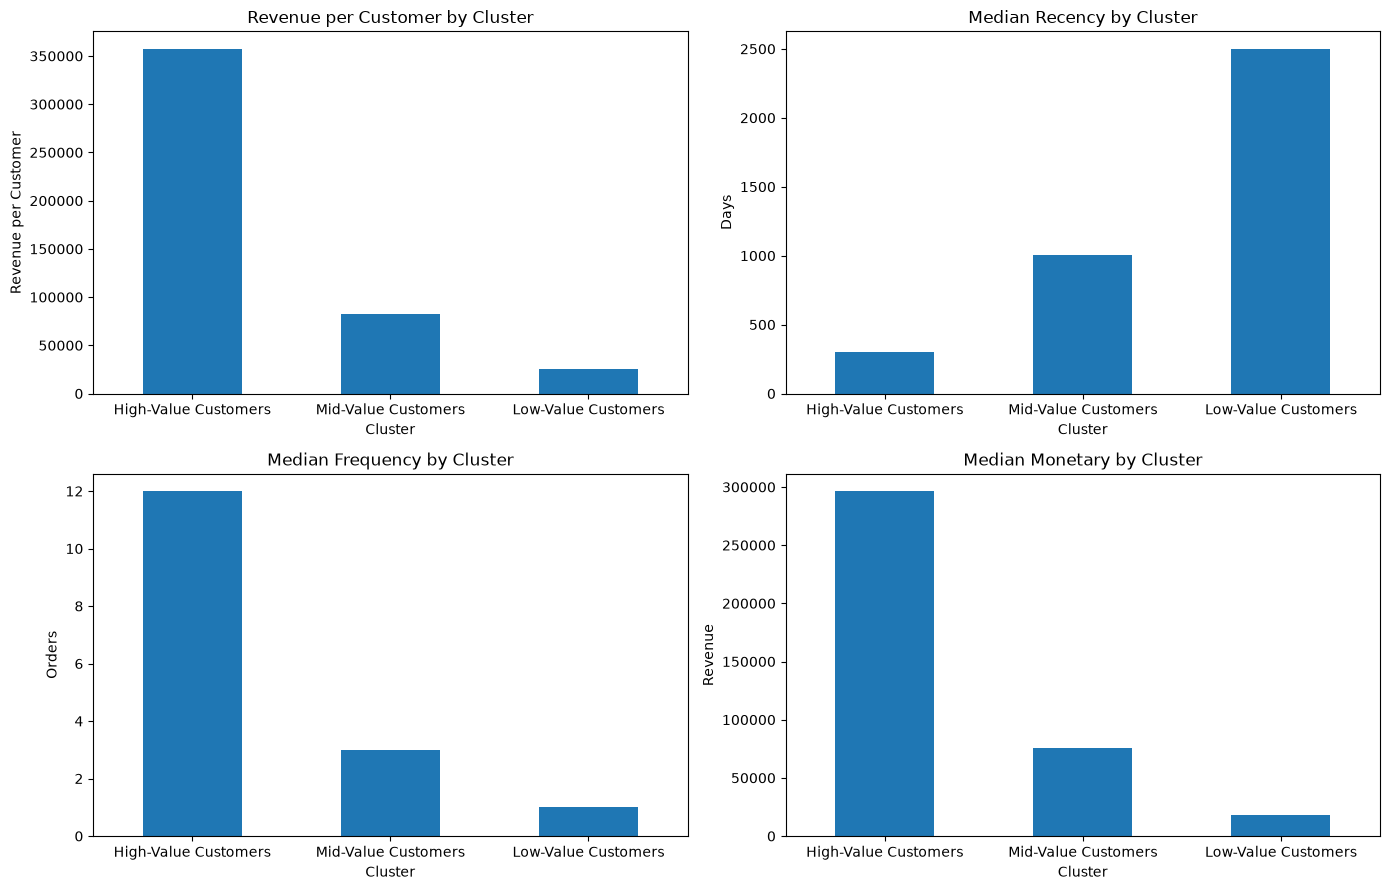

In [6]:
metric_charts = [("Revenue per Customer", "Revenue per Customer by Cluster", "Revenue per Customer"), ("Median Recency", "Median Recency by Cluster", "Days"), ("Median Frequency", "Median Frequency by Cluster", "Orders"), ("Median Monetary", "Median Monetary by Cluster", "Revenue")]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (metric, title, ylabel) in zip(axes.flat, metric_charts):
    cluster_summary[metric].plot(kind="bar", ax=ax, legend=False, rot=0)
    ax.set(title=title, xlabel="Cluster", ylabel=ylabel)
plt.tight_layout()
plt.show()


In [7]:
supporting_profile = profiling_df.groupby("Cluster").agg(**{"Median Units Purchased": ("Units_Purchased", "median")}).reindex(cluster_summary.index)
display(supporting_profile.style.format({"Median Units Purchased": "{:,.0f}"}))


,Median Units Purchased
Cluster,
High-Value Customers,59
Mid-Value Customers,16
Low-Value Customers,6


In [8]:
engine = get_engine()
transactions = read_sql(engine, "SELECT customer_id, order_id, order_date, SUM(quantity) AS units_purchased, SUM(net_sales) AS revenue FROM intermediate.int_order_items_enriched WHERE is_fulfilled_order GROUP BY customer_id, order_id, order_date")
engine.dispose()
transactions.columns = ["Customer_ID", "Order_ID", "Order_Date", "Units_Purchased", "Revenue"]
transactions["Order_Date"] = pd.to_datetime(transactions["Order_Date"])
first_full_year = transactions["Order_Date"].min().year + int(transactions["Order_Date"].min() > pd.Timestamp(transactions["Order_Date"].min().year, 1, 1))
last_complete_year = transactions["Order_Date"].max().year - int(transactions["Order_Date"].max() < pd.Timestamp(transactions["Order_Date"].max().year, 12, 31))
SNAPSHOT_YEARS = list(range(first_full_year, last_complete_year + 1))
history_check = pd.DataFrame({"Metric": ["First Transaction Date", "Last Transaction Date", "First Full Snapshot Year", "Last Complete Snapshot Year", "Snapshot Count"], "Value": [transactions["Order_Date"].min(), transactions["Order_Date"].max(), first_full_year, last_complete_year, len(SNAPSHOT_YEARS)]})
display(history_check)


,Metric,Value
0,First Transaction Date,2012-07-04 00:00:00
1,Last Transaction Date,2022-12-31 00:00:00
2,First Full Snapshot Year,2013
3,Last Complete Snapshot Year,2022
4,Snapshot Count,10


In [9]:
SEGMENT_ORDER = ["Low-Value Customers", "Mid-Value Customers", "High-Value Customers"]
SEGMENT_RANK = {segment: rank for rank, segment in enumerate(SEGMENT_ORDER)}
def build_rfm_snapshot(dataframe, year):
    snapshot_date = pd.Timestamp(year, 12, 31)
    available = dataframe[dataframe["Order_Date"] <= snapshot_date]
    snapshot = available.groupby("Customer_ID").agg(Last_Purchase=("Order_Date", "max"), Frequency=("Order_ID", "nunique"), Monetary=("Revenue", "sum"), Units_Purchased=("Units_Purchased", "sum")).reset_index()
    snapshot["Recency"] = (snapshot_date - snapshot["Last_Purchase"]).dt.days
    snapshot["AOV"] = snapshot["Monetary"] / snapshot["Frequency"]
    features = snapshot[["Recency", "Frequency", "Monetary"]].copy()
    features[["Frequency", "Monetary"]] = np.log1p(features[["Frequency", "Monetary"]])
    scaled_features = pd.DataFrame(StandardScaler().fit_transform(features), columns=features.columns, index=features.index)
    snapshot["Cluster_ID"] = KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(scaled_features)
    cluster_profiles = scaled_features.assign(Cluster_ID=snapshot["Cluster_ID"]).groupby("Cluster_ID")[["Recency", "Frequency", "Monetary"]].mean()
    cluster_value = cluster_profiles["Frequency"] + cluster_profiles["Monetary"] - cluster_profiles["Recency"]
    segment_map = dict(zip(cluster_value.sort_values().index, SEGMENT_ORDER))
    snapshot["Segment"] = snapshot["Cluster_ID"].map(segment_map)
    snapshot["Year"] = year
    return snapshot[["Customer_ID", "Year", "Segment", "Recency", "Frequency", "Monetary", "AOV", "Units_Purchased"]]
annual_snapshots = pd.concat([build_rfm_snapshot(transactions, year) for year in SNAPSHOT_YEARS], ignore_index=True)


Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Year,,,
2013,10841,17357,15559
2014,17077,20889,18952
2015,17237,26162,22265
2016,18083,28321,25682
2017,19242,30519,27140
2018,19658,32422,28564
2019,20583,33145,28812
2020,21997,33237,28838
2021,24243,32926,28222


Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Year,,,
2013,24.78%,39.67%,35.56%
2014,30.00%,36.70%,33.30%
2015,26.25%,39.84%,33.91%
2016,25.09%,39.29%,35.63%
2017,25.02%,39.69%,35.29%
2018,24.38%,40.20%,35.42%
2019,24.94%,40.16%,34.91%
2020,26.16%,39.53%,34.30%
2021,28.39%,38.56%,33.05%


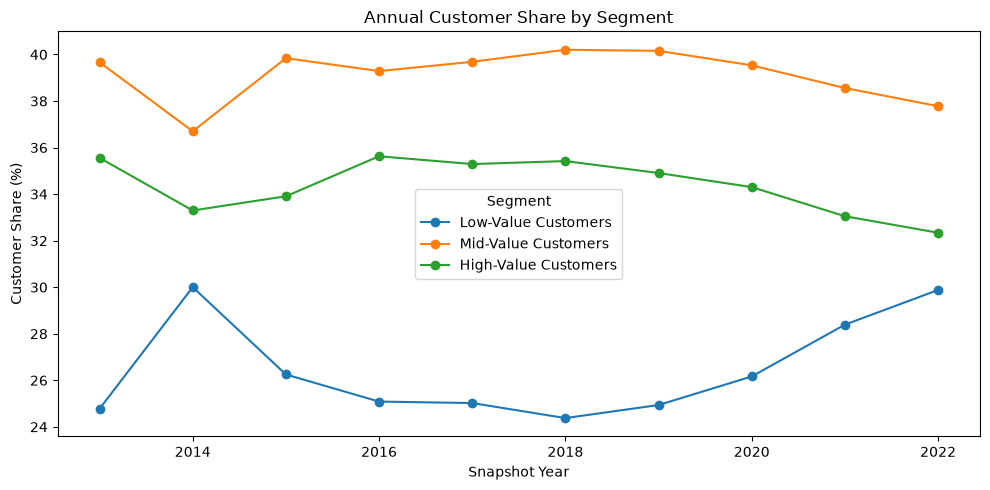

In [10]:
annual_segment_counts = annual_snapshots.pivot_table(index="Year", columns="Segment", values="Customer_ID", aggfunc="nunique").reindex(columns=SEGMENT_ORDER).fillna(0).astype(int)
annual_segment_share = annual_segment_counts.div(annual_segment_counts.sum(axis=1), axis=0) * 100
display(annual_segment_counts)
display(annual_segment_share.style.format("{:.2f}%"))
ax = annual_segment_share.plot(figsize=(10, 5), marker="o")
ax.set(title="Annual Customer Share by Segment", xlabel="Snapshot Year", ylabel="Customer Share (%)")
plt.tight_layout()
plt.show()


In [11]:
transition_frames = []
migration_count_matrices = {}
migration_rate_matrices = {}
for previous_year, current_year in zip(SNAPSHOT_YEARS[:-1], SNAPSHOT_YEARS[1:]):
    previous = annual_snapshots.loc[annual_snapshots["Year"] == previous_year, ["Customer_ID", "Segment"]].rename(columns={"Segment": "Previous Segment"})
    current = annual_snapshots.loc[annual_snapshots["Year"] == current_year].rename(columns={"Segment": "Current Segment"})
    transition = previous.merge(current, on="Customer_ID", how="inner")
    transition["Previous Year"] = previous_year
    transition["Year"] = current_year
    transition["Previous Rank"] = transition["Previous Segment"].map(SEGMENT_RANK)
    transition["Current Rank"] = transition["Current Segment"].map(SEGMENT_RANK)
    transition["Movement"] = np.select([transition["Current Rank"] > transition["Previous Rank"], transition["Current Rank"] < transition["Previous Rank"]], ["Upgrade", "Downgrade"], default="Stay")
    count_matrix = pd.crosstab(transition["Previous Segment"], transition["Current Segment"]).reindex(index=SEGMENT_ORDER, columns=SEGMENT_ORDER, fill_value=0)
    rate_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0) * 100
    transition_frames.append(transition)
    migration_count_matrices[(previous_year, current_year)] = count_matrix
    migration_rate_matrices[(previous_year, current_year)] = rate_matrix
    display(count_matrix.style.set_caption(f"Segment Migration Count: {previous_year} to {current_year}"))
    display(rate_matrix.style.format("{:.2f}%").set_caption(f"Segment Migration Row %: {previous_year} to {current_year}"))
transitions = pd.concat(transition_frames, ignore_index=True)


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,6186,2479,2176
Mid-Value Customers,8869,5201,3287
High-Value Customers,1966,849,12744


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,57.06%,22.87%,20.07%
Mid-Value Customers,51.10%,29.96%,18.94%
High-Value Customers,12.64%,5.46%,81.91%


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,11261,4091,1725
Mid-Value Customers,5727,11632,3530
High-Value Customers,231,1858,16863


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,65.94%,23.96%,10.10%
Mid-Value Customers,27.42%,55.68%,16.90%
High-Value Customers,1.22%,9.80%,88.98%


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,12518,3853,866
Mid-Value Customers,5488,16387,4287
High-Value Customers,76,1707,20482


...

Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,91.72%,7.95%,0.34%
Mid-Value Customers,9.37%,84.32%,6.31%
High-Value Customers,0.00%,7.41%,92.59%


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,20437,1531,29
Mid-Value Customers,3782,27606,1849
High-Value Customers,0,2494,26344


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,92.91%,6.96%,0.13%
Mid-Value Customers,11.38%,83.06%,5.56%
High-Value Customers,0.00%,8.65%,91.35%


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,22556,1672,15
Mid-Value Customers,3303,27644,1979
High-Value Customers,0,2179,26043


Current Segment,Low-Value Customers,Mid-Value Customers,High-Value Customers
Previous Segment,,,
Low-Value Customers,93.04%,6.90%,0.06%
Mid-Value Customers,10.03%,83.96%,6.01%
High-Value Customers,0.00%,7.72%,92.28%


Movement,Previous Year,Year,Observed Customers,Stay,Stay Rate %,Upgrade,Upgrade Rate %,Downgrade,Downgrade Rate %
0,2013,2014,"43,757","24,131",55.15%,"7,942",18.15%,"11,684",26.70%
1,2014,2015,"56,918","39,756",69.85%,"9,346",16.42%,"7,816",13.73%
2,2015,2016,"65,664","49,387",75.21%,"9,006",13.72%,"7,271",11.07%
3,2016,2017,"72,086","57,791",80.17%,"7,087",9.83%,"7,208",10.00%
4,2017,2018,"76,901","64,462",83.82%,"6,612",8.60%,"5,827",7.58%
5,2018,2019,"80,644","71,423",88.57%,"4,224",5.24%,"4,997",6.20%
6,2019,2020,"82,540","73,503",89.05%,"3,796",4.60%,"5,241",6.35%
7,2020,2021,"84,072","74,387",88.48%,"3,409",4.05%,"6,276",7.47%
8,2021,2022,"85,391","76,243",89.29%,"3,666",4.29%,"5,482",6.42%


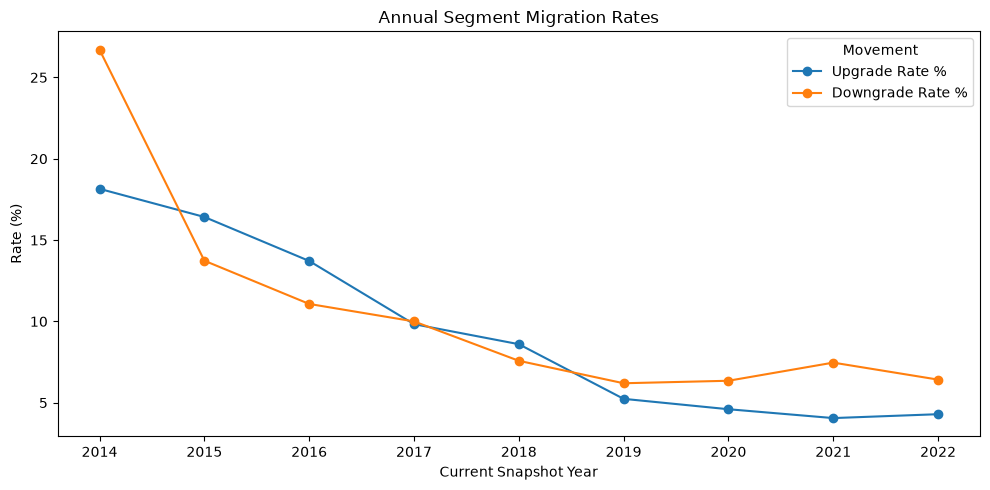

In [12]:
movement_counts = transitions.pivot_table(index=["Previous Year", "Year"], columns="Movement", values="Customer_ID", aggfunc="size", fill_value=0)
migration_summary = movement_counts.reindex(columns=["Stay", "Upgrade", "Downgrade"], fill_value=0).reset_index()
migration_summary["Observed Customers"] = migration_summary[["Stay", "Upgrade", "Downgrade"]].sum(axis=1)
migration_summary["Stay Rate %"] = migration_summary["Stay"] / migration_summary["Observed Customers"] * 100
migration_summary["Upgrade Rate %"] = migration_summary["Upgrade"] / migration_summary["Observed Customers"] * 100
migration_summary["Downgrade Rate %"] = migration_summary["Downgrade"] / migration_summary["Observed Customers"] * 100
migration_summary = migration_summary[["Previous Year", "Year", "Observed Customers", "Stay", "Stay Rate %", "Upgrade", "Upgrade Rate %", "Downgrade", "Downgrade Rate %"]]
display(migration_summary.style.format({"Observed Customers": "{:,.0f}", "Stay": "{:,.0f}", "Stay Rate %": "{:.2f}%", "Upgrade": "{:,.0f}", "Upgrade Rate %": "{:.2f}%", "Downgrade": "{:,.0f}", "Downgrade Rate %": "{:.2f}%"}))
ax = migration_summary.set_index("Year")[["Upgrade Rate %", "Downgrade Rate %"]].plot(figsize=(10, 5), marker="o")
ax.set(title="Annual Segment Migration Rates", xlabel="Current Snapshot Year", ylabel="Rate (%)")
plt.tight_layout()
plt.show()


In [13]:
MIN_SAMPLE_SIZE = 100
segment_movement_counts = transitions.pivot_table(index=["Previous Year", "Year", "Previous Segment"], columns="Movement", values="Customer_ID", aggfunc="size", fill_value=0)
segment_migration_summary = segment_movement_counts.reindex(columns=["Stay", "Upgrade", "Downgrade"], fill_value=0).reset_index()
segment_migration_summary["Observed Customers"] = segment_migration_summary[["Stay", "Upgrade", "Downgrade"]].sum(axis=1)
segment_migration_summary["Stay Rate %"] = segment_migration_summary["Stay"] / segment_migration_summary["Observed Customers"] * 100
segment_migration_summary["Upgrade Rate %"] = segment_migration_summary["Upgrade"] / segment_migration_summary["Observed Customers"] * 100
segment_migration_summary["Downgrade Rate %"] = segment_migration_summary["Downgrade"] / segment_migration_summary["Observed Customers"] * 100
segment_migration_summary = segment_migration_summary[segment_migration_summary["Observed Customers"] >= MIN_SAMPLE_SIZE]
display(segment_migration_summary.style.format({"Observed Customers": "{:,.0f}", "Stay": "{:,.0f}", "Stay Rate %": "{:.2f}%", "Upgrade": "{:,.0f}", "Upgrade Rate %": "{:.2f}%", "Downgrade": "{:,.0f}", "Downgrade Rate %": "{:.2f}%"}))


Movement,Previous Year,Year,Previous Segment,Stay,Upgrade,Downgrade,Observed Customers,Stay Rate %,Upgrade Rate %,Downgrade Rate %
0,2013,2014,High-Value Customers,"12,744",0,"2,815","15,559",81.91%,0.00%,18.09%
1,2013,2014,Low-Value Customers,"6,186","4,655",0,"10,841",57.06%,42.94%,0.00%
2,2013,2014,Mid-Value Customers,"5,201","3,287","8,869","17,357",29.96%,18.94%,51.10%
3,2014,2015,High-Value Customers,"16,863",0,"2,089","18,952",88.98%,0.00%,11.02%
4,2014,2015,Low-Value Customers,"11,261","5,816",0,"17,077",65.94%,34.06%,0.00%
5,2014,2015,Mid-Value Customers,"11,632","3,530","5,727","20,889",55.68%,16.90%,27.42%
6,2015,2016,High-Value Customers,"20,482",0,"1,783","22,265",91.99%,0.00%,8.01%
7,2015,2016,Low-Value Customers,"12,518","4,719",0,"17,237",72.62%,27.38%,0.00%
8,2015,2016,Mid-Value Customers,"16,387","4,287","5,488","26,162",62.64%,16.39%,20.98%
9,2016,2017,High-Value Customers,"23,492",0,"2,190","25,682",91.47%,0.00%,8.53%


In [14]:
mid_segment = "Mid-Value Customers"
mid_benchmarks = annual_snapshots[annual_snapshots["Segment"] == mid_segment].groupby("Year").agg(Mid_Median_Recency=("Recency", "median"), Mid_Median_Frequency=("Frequency", "median"), Mid_Median_Monetary=("Monetary", "median"))
transitions = transitions.merge(mid_benchmarks, left_on="Year", right_index=True, how="left")
mid_stay_count = transitions[(transitions["Previous Segment"] == mid_segment) & (transitions["Current Segment"] == mid_segment)].groupby("Customer_ID").size()
transitions["Mid Stay Years"] = transitions["Customer_ID"].map(mid_stay_count).fillna(0).astype(int)
high_downgrade = (transitions["Previous Segment"] == "High-Value Customers") & (transitions["Movement"] == "Downgrade")
mid_downgrade = (transitions["Previous Segment"] == mid_segment) & (transitions["Current Segment"] == "Low-Value Customers")
mid_potential = (transitions["Previous Segment"] == mid_segment) & (transitions["Current Segment"] == mid_segment) & (transitions["Mid Stay Years"] >= 2) & (transitions["Recency"] <= transitions["Mid_Median_Recency"]) & ((transitions["Frequency"] > transitions["Mid_Median_Frequency"]) | (transitions["Monetary"] > transitions["Mid_Median_Monetary"]))
low_upgrade = (transitions["Previous Segment"] == "Low-Value Customers") & (transitions["Movement"] == "Upgrade")
transitions["Candidate Type"] = np.select([high_downgrade, mid_downgrade, mid_potential, low_upgrade], ["High-Value Downgrade", "Mid-Value to Low-Value", "Multi-Year Mid-Value Potential", "Successful Low-Value Upgrade"], default="")
candidate_customers = transitions.loc[transitions["Candidate Type"] != "", ["Customer_ID", "Previous Segment", "Current Segment", "Year", "Recency", "Frequency", "Monetary", "AOV", "Units_Purchased", "Candidate Type"]].sort_values(["Candidate Type", "Year", "Customer_ID"])
candidate_counts = candidate_customers.groupby(["Candidate Type", "Year"])["Customer_ID"].nunique().unstack(fill_value=0)
display(candidate_counts)
display(candidate_customers.head(20).style.format({"Monetary": "{:,.2f}", "AOV": "{:,.2f}", "Units_Purchased": "{:,.0f}"}))


Year,2014,2015,2016,2017,2018,2019,2020,2021,2022
Candidate Type,,,,,,,,,
High-Value Downgrade,2815,2089,1783,2190,1949,2026,2134,2494,2179
Mid-Value to Low-Value,8869,5727,5488,5018,3878,2971,3107,3782,3303
Multi-Year Mid-Value Potential,1780,2497,4013,5461,6658,6708,6978,6979,7037
Successful Low-Value Upgrade,4655,5816,4719,3891,3476,2048,1705,1560,1687


,Customer_ID,Previous Segment,Current Segment,Year,Recency,Frequency,Monetary,AOV,Units_Purchased,Candidate Type
5,8,High-Value Customers,Low-Value Customers,2014,601,2,"49,655.41","24,827.71",7,High-Value Downgrade
11,22,High-Value Customers,Low-Value Customers,2014,561,3,"98,436.60","32,812.20",16,High-Value Downgrade
13,24,High-Value Customers,Low-Value Customers,2014,613,3,"24,981.22","8,327.07",11,High-Value Downgrade
37,81,High-Value Customers,Mid-Value Customers,2014,444,2,"69,377.25","34,688.62",16,High-Value Downgrade
53,132,High-Value Customers,Mid-Value Customers,2014,376,3,"24,261.92","8,087.31",12,High-Value Downgrade
105,388,High-Value Customers,Mid-Value Customers,2014,375,2,"57,889.64","28,944.82",11,High-Value Downgrade
106,390,High-Value Customers,Low-Value Customers,2014,484,2,"75,126.97","37,563.49",9,High-Value Downgrade
117,427,High-Value Customers,Mid-Value Customers,2014,401,2,"70,559.53","35,279.76",12,High-Value Downgrade
122,439,High-Value Customers,Low-Value Customers,2014,518,3,"45,514.15","15,171.38",8,High-Value Downgrade
160,528,High-Value Customers,Mid-Value Customers,2014,410,2,"38,890.81","19,445.40",17,High-Value Downgrade


In [15]:
engine = get_engine()
order_lines = read_sql(engine, "SELECT i.customer_id, i.order_id, i.order_date, i.product_id, p.category, i.quantity, i.discount_amount, i.net_sales FROM intermediate.int_order_items_enriched AS i INNER JOIN staging.stg_products AS p ON i.product_id = p.product_id WHERE i.is_fulfilled_order")
customer_attributes = read_sql(engine, "SELECT customer_id, acquisition_channel, region FROM marts.mart_customer")
engine.dispose()
order_lines.columns = ["Customer_ID", "Order_ID", "Order_Date", "Product_ID", "Category", "Quantity", "Discount", "Revenue"]
customer_attributes.columns = ["Customer_ID", "Acquisition Channel", "Region"]
order_lines["Order_Date"] = pd.to_datetime(order_lines["Order_Date"])
order_lines["Year"] = order_lines["Order_Date"].dt.year


In [16]:
mid_outcomes = transitions.loc[(transitions["Previous Segment"] == mid_segment) & (transitions["Current Segment"].isin([mid_segment, "High-Value Customers"])), ["Customer_ID", "Previous Year", "Year", "Previous Segment", "Current Segment"]].rename(columns={"Previous Year": "Year", "Year": "Outcome Year"})
predictor_snapshots = annual_snapshots.rename(columns={"Segment": "Segment at t"})
comparison_panel = mid_outcomes.merge(predictor_snapshots, on=["Customer_ID", "Year"], how="inner")
mid_t_benchmarks = predictor_snapshots[predictor_snapshots["Segment at t"] == mid_segment].groupby("Year").agg(Mid_Median_Recency_t=("Recency", "median"), Mid_Median_Frequency_t=("Frequency", "median"), Mid_Median_Monetary_t=("Monetary", "median"))
comparison_panel = comparison_panel.merge(mid_t_benchmarks, left_on="Year", right_index=True, how="left")
potential_at_t = (comparison_panel["Recency"] <= comparison_panel["Mid_Median_Recency_t"]) & ((comparison_panel["Frequency"] > comparison_panel["Mid_Median_Frequency_t"]) | (comparison_panel["Monetary"] > comparison_panel["Mid_Median_Monetary_t"]))
comparison_panel["Group"] = np.select([(comparison_panel["Current Segment"] == mid_segment) & potential_at_t, comparison_panel["Current Segment"] == "High-Value Customers"], ["Group A: Mid-Stay Potential", "Group B: Mid-to-High"], default="")
comparison_panel = comparison_panel[comparison_panel["Group"] != ""]


In [17]:
sample_summary = comparison_panel.groupby("Group").agg(Rows=("Customer_ID", "size"), Unique_Customers=("Customer_ID", "nunique"), Years=("Year", "nunique"))
repeated_customers = comparison_panel.groupby("Customer_ID")["Year"].nunique().gt(1).sum()
sample_check = pd.DataFrame({"Metric": ["Panel Rows", "Unique Customers", "Customers in Multiple Years", "Duplicate Customer-Year Rows"], "Value": [len(comparison_panel), comparison_panel["Customer_ID"].nunique(), repeated_customers, comparison_panel.duplicated(["Customer_ID", "Year"]).sum()]})
sample_by_year = comparison_panel.pivot_table(index="Year", columns="Group", values="Customer_ID", aggfunc="nunique", fill_value=0)
base_missing = comparison_panel[["Customer_ID", "Year", "Group", "Recency", "Frequency", "Monetary", "AOV", "Units_Purchased"]].isna().sum().rename("Missing Values").to_frame()
display(sample_summary)
display(sample_check)
display(sample_by_year)
display(base_missing)


,Rows,Unique_Customers,Years
Group,,,
Group A: Mid-Stay Potential,59265,29039,9
Group B: Mid-to-High,25531,20148,9


,Metric,Value
0,Panel Rows,84796
1,Unique Customers,40601
2,Customers in Multiple Years,23361
3,Duplicate Customer-Year Rows,0


Group,Group A: Mid-Stay Potential,Group B: Mid-to-High
Year,,
2013,1762,3287
2014,5185,3530
2015,5123,4287
2016,6722,3196
2017,7437,3136
2018,8815,2176
2019,7833,2091
2020,8149,1849
2021,8239,1979


,Missing Values
Customer_ID,0
Year,0
Group,0
Recency,0
Frequency,0
Monetary,0
AOV,0
Units_Purchased,0


In [18]:
order_detail = order_lines.groupby(["Customer_ID", "Order_ID", "Order_Date"], as_index=False).agg(Units=("Quantity", "sum"), Discount=("Discount", "sum"), Revenue=("Revenue", "sum"))
order_detail["Year"] = order_detail["Order_Date"].dt.year
order_detail["Month"] = order_detail["Order_Date"].dt.to_period("M").astype(str)
order_detail = order_detail.sort_values(["Customer_ID", "Order_Date", "Order_ID"])
order_detail["Days Between Purchases"] = order_detail.groupby("Customer_ID")["Order_Date"].diff().dt.days
order_detail["Discounted Order"] = order_detail["Discount"] > 0
order_detail["Discounted Revenue"] = order_detail["Revenue"].where(order_detail["Discounted Order"], 0)
annual_order_behavior = order_detail.groupby(["Customer_ID", "Year"]).agg(**{"Orders in Year": ("Order_ID", "nunique"), "Revenue in Year": ("Revenue", "sum"), "Units in Year": ("Units", "sum"), "Active Months": ("Month", "nunique"), "Median Days Between Purchases": ("Days Between Purchases", "median"), "Purchase Interval Std": ("Days Between Purchases", "std"), "Discounted Order Rate": ("Discounted Order", "mean"), "Average Discount per Order": ("Discount", "mean"), "Discounted Revenue": ("Discounted Revenue", "sum")}).reset_index()
annual_order_behavior["AOV in Year"] = annual_order_behavior["Revenue in Year"] / annual_order_behavior["Orders in Year"]
annual_order_behavior["Units per Order"] = annual_order_behavior["Units in Year"] / annual_order_behavior["Orders in Year"]
annual_order_behavior["Discounted Revenue Share"] = annual_order_behavior["Discounted Revenue"] / annual_order_behavior["Revenue in Year"]
annual_product_behavior = order_lines.groupby(["Customer_ID", "Year"]).agg(**{"Distinct Products": ("Product_ID", "nunique"), "Distinct Categories": ("Category", "nunique")}).reset_index()
customer_category_revenue = order_lines.groupby(["Customer_ID", "Year", "Category"], as_index=False)["Revenue"].sum()
category_concentration = customer_category_revenue.groupby(["Customer_ID", "Year"])["Revenue"].agg(["max", "sum"]).reset_index()
category_concentration["Category Concentration"] = category_concentration["max"] / category_concentration["sum"]
annual_behavior = annual_order_behavior.merge(annual_product_behavior, on=["Customer_ID", "Year"], how="outer")
annual_behavior = annual_behavior.merge(category_concentration[["Customer_ID", "Year", "Category Concentration"]], on=["Customer_ID", "Year"], how="left")
active_year_matrix = transactions.assign(Year=transactions["Order_Date"].dt.year).drop_duplicates(["Customer_ID", "Year"]).assign(Active=1).pivot(index="Customer_ID", columns="Year", values="Active").fillna(0).sort_index(axis=1).cumsum(axis=1)
active_year_counts = active_year_matrix.reindex(columns=SNAPSHOT_YEARS).stack().rename("Active Years").reset_index()
comparison_panel = comparison_panel.merge(annual_behavior, on=["Customer_ID", "Year"], how="left")
comparison_panel = comparison_panel.merge(active_year_counts, on=["Customer_ID", "Year"], how="left")
comparison_panel = comparison_panel.merge(customer_attributes, on="Customer_ID", how="left")
ZERO_ACTIVITY_FEATURES = ["Orders in Year", "Revenue in Year", "Units in Year", "Active Months", "Distinct Products", "Distinct Categories", "Discounted Revenue"]
comparison_panel[ZERO_ACTIVITY_FEATURES] = comparison_panel[ZERO_ACTIVITY_FEATURES].fillna(0)


In [19]:
NUMERIC_FEATURES = ["Recency", "Frequency", "Monetary", "AOV", "Units_Purchased", "Orders in Year", "Revenue in Year", "AOV in Year", "Units per Order", "Median Days Between Purchases", "Purchase Interval Std", "Active Months", "Active Years", "Distinct Products", "Distinct Categories", "Category Concentration", "Discounted Order Rate", "Average Discount per Order", "Discounted Revenue Share"]
descriptive_rows = []
for feature in NUMERIC_FEATURES:
    for group, values in comparison_panel.groupby("Group")[feature]:
        values = values.dropna()
        descriptive_rows.append({"Feature": feature, "Group": group, "Count": values.size, "Mean": values.mean(), "Median": values.median(), "Std": values.std(), "P25": values.quantile(0.25), "P75": values.quantile(0.75)})
numeric_descriptive = pd.DataFrame(descriptive_rows)
display(numeric_descriptive.style.format({"Count": "{:,.0f}", "Mean": "{:,.2f}", "Median": "{:,.2f}", "Std": "{:,.2f}", "P25": "{:,.2f}", "P75": "{:,.2f}"}))


,Feature,Group,Count,Mean,Median,Std,P25,P75
0,Recency,Group A: Mid-Stay Potential,"59,265",286.78,216.00,227.36,127.00,415.00
1,Recency,Group B: Mid-to-High,"25,531",461.81,300.00,411.09,169.00,630.00
2,Frequency,Group A: Mid-Stay Potential,"59,265",3.01,3.00,1.25,2.00,4.00
3,Frequency,Group B: Mid-to-High,"25,531",3.32,3.00,1.44,2.00,4.00
4,Monetary,Group A: Mid-Stay Potential,"59,265","70,391.30","66,406.35","34,804.61","45,369.45","89,822.50"
5,Monetary,Group B: Mid-to-High,"25,531","70,117.76","65,124.55","42,925.73","36,239.93","96,817.35"
6,AOV,Group A: Mid-Stay Potential,"59,265","27,571.64","23,646.95","18,253.45","14,615.12","35,192.04"
7,AOV,Group B: Mid-to-High,"25,531","22,268.54","19,364.47","13,889.38","12,526.48","28,736.26"
8,Units_Purchased,Group A: Mid-Stay Potential,"59,265",14.91,14.00,6.87,10.00,19.00
9,Units_Purchased,Group B: Mid-to-High,"25,531",16.20,15.00,8.25,10.00,21.00


In [20]:
def outlier_rate(values):
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).mean() * 100
distribution_rows = []
for feature in NUMERIC_FEATURES:
    for group, values in comparison_panel.groupby("Group")[feature]:
        values = values.dropna()
        distribution_rows.append({"Feature": feature, "Group": group, "Skewness": values.skew(), "IQR Outlier %": outlier_rate(values)})
distribution_check = pd.DataFrame(distribution_rows)
DISCRETE_OR_BOUNDED_FEATURES = ["Frequency", "Units_Purchased", "Orders in Year", "Units in Year", "Units per Order", "Active Months", "Active Years", "Distinct Products", "Distinct Categories", "Category Concentration", "Discounted Order Rate", "Discounted Revenue Share"]
statistical_rows = []
for feature in NUMERIC_FEATURES:
    group_a = comparison_panel.loc[comparison_panel["Group"] == "Group A: Mid-Stay Potential", feature].dropna()
    group_b = comparison_panel.loc[comparison_panel["Group"] == "Group B: Mid-to-High", feature].dropna()
    feature_distribution = distribution_check[distribution_check["Feature"] == feature]
    use_parametric = feature not in DISCRETE_OR_BOUNDED_FEATURES and feature_distribution["Skewness"].abs().max() < 1 and feature_distribution["IQR Outlier %"].max() < 5
    test_name = "Welch t-test" if use_parametric else "Mann-Whitney U"
    p_value = ttest_ind(group_b, group_a, equal_var=False).pvalue if use_parametric else mannwhitneyu(group_b, group_a, alternative="two-sided").pvalue
    pooled_std = np.sqrt(((len(group_a) - 1) * group_a.var() + (len(group_b) - 1) * group_b.var()) / (len(group_a) + len(group_b) - 2))
    effect_size = (group_b.mean() - group_a.mean()) / pooled_std if use_parametric and pooled_std else 2 * mannwhitneyu(group_b, group_a, alternative="two-sided").statistic / (len(group_a) * len(group_b)) - 1
    effect_name = "Cohen's d" if use_parametric else "Rank-biserial"
    median_a = group_a.median()
    median_b = group_b.median()
    statistical_rows.append({"Feature": feature, "Group A Median": median_a, "Group B Median": median_b, "Absolute Difference": median_b - median_a, "Percentage Difference %": (median_b - median_a) / abs(median_a) * 100 if median_a else np.nan, "P-Value": p_value, "Effect Size": effect_size, "Effect Size Type": effect_name, "Test": test_name, "Group A N": len(group_a), "Group B N": len(group_b)})
feature_comparison = pd.DataFrame(statistical_rows)
feature_comparison["Absolute Effect Size"] = feature_comparison["Effect Size"].abs()
feature_comparison = feature_comparison.sort_values("Absolute Effect Size", ascending=False)
display(distribution_check.style.format({"Skewness": "{:.2f}", "IQR Outlier %": "{:.2f}%"}))
display(feature_comparison.style.format({"Group A Median": "{:,.2f}", "Group B Median": "{:,.2f}", "Absolute Difference": "{:,.2f}", "Percentage Difference %": "{:.2f}%", "P-Value": "{:.4g}", "Effect Size": "{:.3f}", "Absolute Effect Size": "{:.3f}", "Group A N": "{:,.0f}", "Group B N": "{:,.0f}"}))


,Feature,Group,Skewness,IQR Outlier %
0,Recency,Group A: Mid-Stay Potential,1.11,3.75%
1,Recency,Group B: Mid-to-High,1.43,4.88%
2,Frequency,Group A: Mid-Stay Potential,0.33,0.03%
3,Frequency,Group B: Mid-to-High,0.39,0.29%
4,Monetary,Group A: Mid-Stay Potential,0.79,2.02%
5,Monetary,Group B: Mid-to-High,0.74,1.19%
6,AOV,Group A: Mid-Stay Potential,1.71,4.34%
7,AOV,Group B: Mid-to-High,1.60,3.34%
8,Units_Purchased,Group A: Mid-Stay Potential,0.75,1.60%
9,Units_Purchased,Group B: Mid-to-High,0.61,1.28%


,Feature,Group A Median,Group B Median,Absolute Difference,Percentage Difference %,P-Value,Effect Size,Effect Size Type,Test,Group A N,Group B N,Absolute Effect Size
9,Median Days Between Purchases,570.00,365.50,-204.50,-35.88%,0,-0.304,Rank-biserial,Mann-Whitney U,"36,552","11,478",0.304
0,Recency,216.00,300.00,84.00,38.89%,0,0.238,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.238
6,Revenue in Year,"14,315.85","3,964.49","-10,351.36",-72.31%,0,-0.231,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.231
10,Purchase Interval Std,387.57,262.34,-125.24,-32.31%,3.752e-44,-0.206,Rank-biserial,Mann-Whitney U,"5,444","2,113",0.206
3,AOV,"23,646.95","19,364.47","-4,282.48",-18.11%,0,-0.170,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.170
7,AOV in Year,"22,030.56","15,279.56","-6,751.00",-30.64%,9.64e-199,-0.170,Rank-biserial,Mann-Whitney U,"42,545","13,810",0.170
14,Distinct Categories,1.00,1.00,0.00,0.00%,0,-0.161,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.161
11,Active Months,1.00,1.00,0.00,0.00%,0,-0.151,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.151
5,Orders in Year,1.00,1.00,0.00,0.00%,0,-0.149,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.149
13,Distinct Products,1.00,1.00,0.00,0.00%,3.605e-283,-0.143,Rank-biserial,Mann-Whitney U,"59,265","25,531",0.143


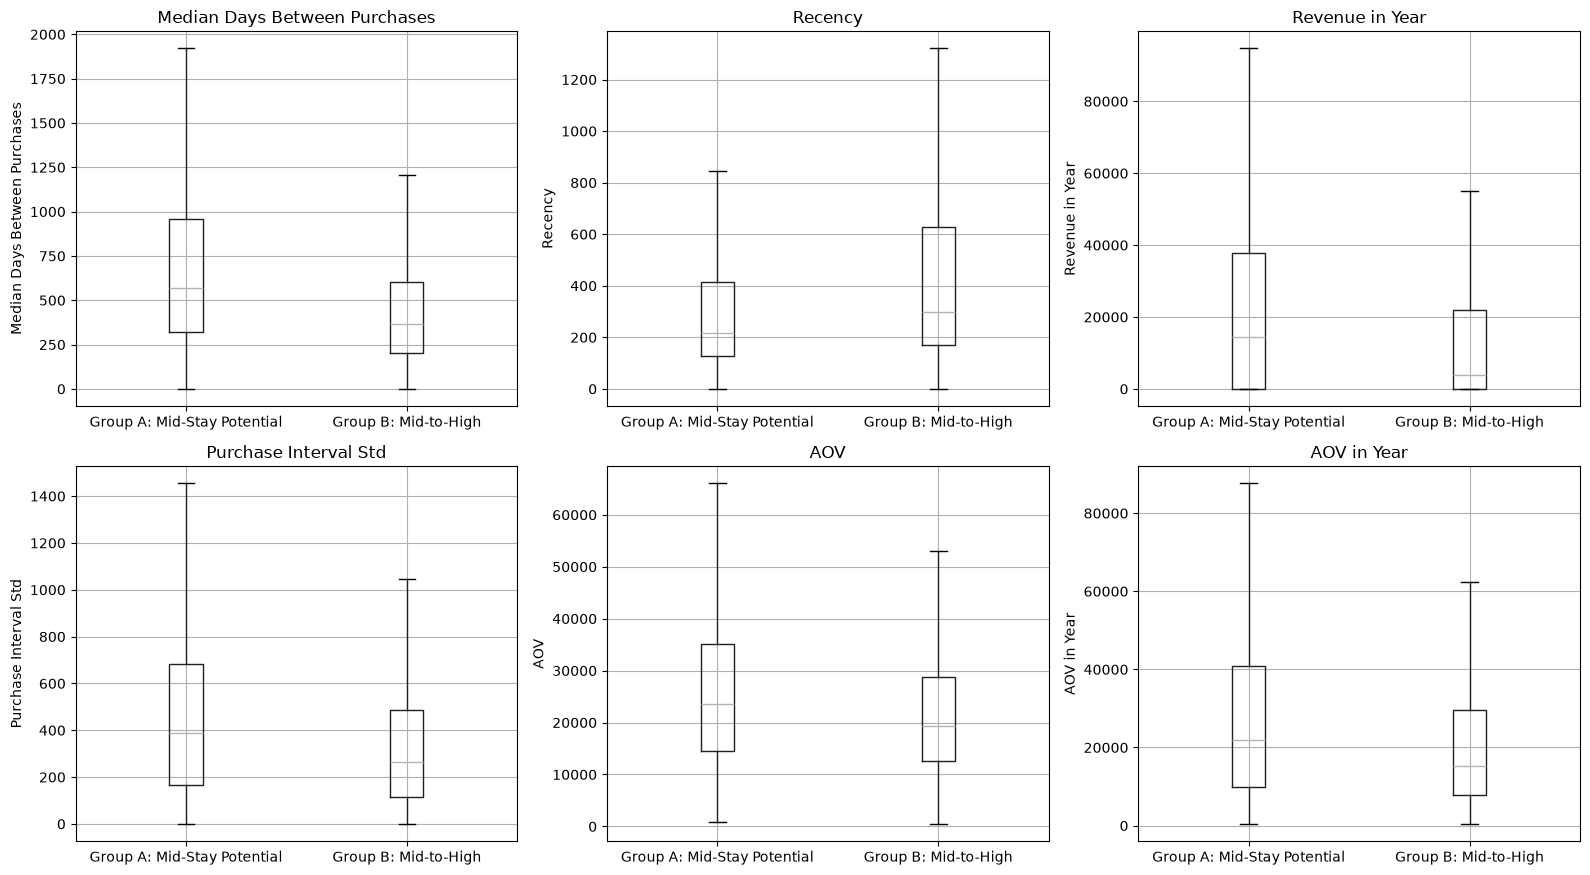

In [21]:
TOP_FEATURE_COUNT = 6
top_numeric_features = feature_comparison.head(TOP_FEATURE_COUNT)["Feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flat, top_numeric_features):
    comparison_panel.boxplot(column=feature, by="Group", ax=ax, showfliers=False)
    ax.set(title=feature, xlabel="", ylabel=feature)
fig.suptitle("")
plt.tight_layout()
plt.show()


,count,mean,median,std,min,max
Group,,,,,,
Group A: Mid-Stay Potential,"42,356.00",659.73,527.00,547.89,0.00,"3,390.00"
Group B: Mid-to-High,"13,733.00",425.87,335.00,374.52,0.00,"2,862.00"


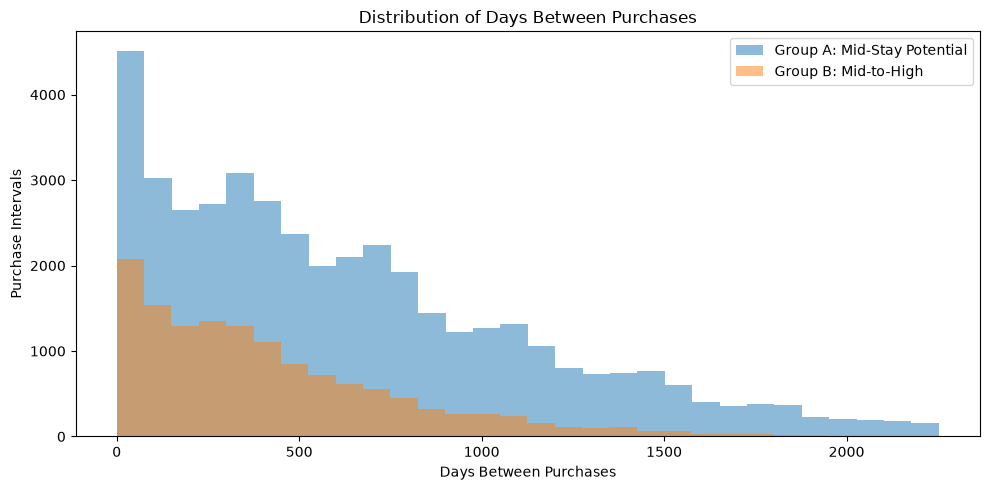

In [22]:
panel_keys = comparison_panel[["Customer_ID", "Year", "Group"]].drop_duplicates()
panel_order_gaps = panel_keys.merge(order_detail[["Customer_ID", "Year", "Days Between Purchases"]], on=["Customer_ID", "Year"], how="inner").dropna(subset=["Days Between Purchases"])
cadence_distribution = panel_order_gaps.groupby("Group")["Days Between Purchases"].agg(["count", "mean", "median", "std", "min", "max"])
display(cadence_distribution.style.format("{:,.2f}"))
gap_limit = panel_order_gaps["Days Between Purchases"].quantile(0.99)
fig, ax = plt.subplots(figsize=(10, 5))
for group, values in panel_order_gaps.groupby("Group")["Days Between Purchases"]:
    ax.hist(values[values <= gap_limit], bins=30, alpha=0.5, label=group)
ax.set(title="Distribution of Days Between Purchases", xlabel="Days Between Purchases", ylabel="Purchase Intervals")
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
panel_category_revenue = panel_keys.merge(order_lines[["Customer_ID", "Year", "Category", "Revenue"]], on=["Customer_ID", "Year"], how="inner")
top_category_revenue = panel_category_revenue.groupby(["Group", "Category"])["Revenue"].sum().groupby(level=0, group_keys=False).nlargest(10).rename("Revenue").reset_index()
panel_categories = panel_category_revenue[["Customer_ID", "Year", "Group", "Category"]].drop_duplicates()
category_customer_counts = panel_categories.groupby(["Category", "Group"]).size().unstack(fill_value=0)
category_penetration = category_customer_counts.div(panel_keys["Group"].value_counts(), axis=1) * 100
category_penetration["Difference B - A pp"] = category_penetration["Group B: Mid-to-High"] - category_penetration["Group A: Mid-Stay Potential"]
category_test_rows = []
for category, counts in category_customer_counts.iterrows():
    observed = np.array([[counts["Group A: Mid-Stay Potential"], len(panel_keys[panel_keys["Group"] == "Group A: Mid-Stay Potential"]) - counts["Group A: Mid-Stay Potential"]], [counts["Group B: Mid-to-High"], len(panel_keys[panel_keys["Group"] == "Group B: Mid-to-High"]) - counts["Group B: Mid-to-High"]]])
    chi2, p_value, _, expected = chi2_contingency(observed)
    valid_test = expected.min() >= 5
    direction = np.sign(category_penetration.loc[category, "Difference B - A pp"] )
    category_test_rows.append({"Category": category, "P-Value": p_value if valid_test else np.nan, "Signed Phi": direction * np.sqrt(chi2 / observed.sum()) if valid_test else np.nan, "Valid Chi-Square": valid_test})
category_comparison = category_penetration.reset_index().merge(pd.DataFrame(category_test_rows), on="Category").sort_values("Difference B - A pp", key=abs, ascending=False)
display(top_category_revenue.style.format({"Revenue": "{:,.2f}"}))
display(category_comparison.style.format({"Group A: Mid-Stay Potential": "{:.2f}%", "Group B: Mid-to-High": "{:.2f}%", "Difference B - A pp": "{:.2f}", "P-Value": "{:.4g}", "Signed Phi": "{:.3f}"}))


,Group,Category,Revenue
0,Group A: Mid-Stay Potential,streetwear,"1,163,279,578.66"
1,Group A: Mid-Stay Potential,outdoor,"156,894,931.07"
2,Group A: Mid-Stay Potential,casual,"32,365,186.58"
3,Group A: Mid-Stay Potential,genz,"27,540,203.26"
4,Group B: Mid-to-High,streetwear,"289,604,533.36"
5,Group B: Mid-to-High,outdoor,"57,699,667.68"
6,Group B: Mid-to-High,genz,"9,169,780.35"
7,Group B: Mid-to-High,casual,"8,343,078.39"


,Category,Group A: Mid-Stay Potential,Group B: Mid-to-High,Difference B - A pp,P-Value,Signed Phi,Valid Chi-Square
3,streetwear,51.11%,35.83%,-15.28,0,-0.141,True
0,casual,2.87%,1.94%,-0.92,9.209e-15,-0.027,True
1,genz,4.83%,4.13%,-0.70,9.76e-06,-0.015,True
2,outdoor,19.78%,19.55%,-0.23,0.4418,-0.003,True


In [24]:
CATEGORICAL_FEATURES = ["Acquisition Channel", "Region"]
categorical_rate_tables = {}
categorical_test_rows = []
for feature in CATEGORICAL_FEATURES:
    observed = pd.crosstab(comparison_panel["Group"], comparison_panel[feature])
    chi2, p_value, _, expected = chi2_contingency(observed)
    valid_test = expected.min() >= 5
    categorical_rate_tables[feature] = observed.div(observed.sum(axis=1), axis=0) * 100
    categorical_test_rows.append({"Feature": feature, "P-Value": p_value if valid_test else np.nan, "Cramer's V": np.sqrt(chi2 / (observed.to_numpy().sum() * min(observed.shape[0] - 1, observed.shape[1] - 1))) if valid_test else np.nan, "Valid Chi-Square": valid_test})
categorical_test_summary = pd.DataFrame(categorical_test_rows)
for feature, rates in categorical_rate_tables.items():
    display(rates.style.format("{:.2f}%").set_caption(feature))
display(categorical_test_summary.style.format({"P-Value": "{:.4g}", "Cramer's V": "{:.3f}"}))


Acquisition Channel,direct,email_campaign,organic_search,paid_search,referral,social_media
Group,,,,,,
Group A: Mid-Stay Potential,8.29%,12.06%,29.58%,19.75%,10.20%,20.11%
Group B: Mid-to-High,8.12%,11.82%,30.05%,19.72%,9.93%,20.36%


Region,central,east,west
Group,,,
Group A: Mid-Stay Potential,33.24%,54.18%,12.57%
Group B: Mid-to-High,30.12%,53.71%,16.16%


,Feature,P-Value,Cramer's V,Valid Chi-Square
0,Acquisition Channel,0.4485,0.007,True
1,Region,3.503e-49,0.051,True


In [25]:
temporal_rows = []
for year, year_data in comparison_panel.groupby("Year"):
    for feature in top_numeric_features:
        group_a = year_data.loc[year_data["Group"] == "Group A: Mid-Stay Potential", feature].dropna()
        group_b = year_data.loc[year_data["Group"] == "Group B: Mid-to-High", feature].dropna()
        effect_size = 2 * mannwhitneyu(group_b, group_a, alternative="two-sided").statistic / (len(group_a) * len(group_b)) - 1
        temporal_rows.append({"Year": year, "Feature": feature, "Group A Median": group_a.median(), "Group B Median": group_b.median(), "Median Difference": group_b.median() - group_a.median(), "Rank-Biserial Effect": effect_size, "P-Value": mannwhitneyu(group_b, group_a, alternative="two-sided").pvalue})
annual_feature_comparison = pd.DataFrame(temporal_rows)
pooled_effect = feature_comparison.set_index("Feature")["Effect Size"]
annual_feature_comparison["Same Direction as Pooled"] = np.sign(annual_feature_comparison["Rank-Biserial Effect"]) == np.sign(annual_feature_comparison["Feature"].map(pooled_effect))
temporal_consistency_summary = annual_feature_comparison.groupby("Feature").agg(**{"Years Observed": ("Year", "nunique"), "Sign Consistency %": ("Same Direction as Pooled", lambda values: values.mean() * 100), "Median Annual Effect": ("Rank-Biserial Effect", "median"), "Minimum Annual Effect": ("Rank-Biserial Effect", "min"), "Maximum Annual Effect": ("Rank-Biserial Effect", "max")}).sort_values("Sign Consistency %", ascending=False)
display(annual_feature_comparison.style.format({"Group A Median": "{:,.2f}", "Group B Median": "{:,.2f}", "Median Difference": "{:,.2f}", "Rank-Biserial Effect": "{:.3f}", "P-Value": "{:.4g}"}))
display(temporal_consistency_summary.style.format({"Years Observed": "{:,.0f}", "Sign Consistency %": "{:.2f}%", "Median Annual Effect": "{:.3f}", "Minimum Annual Effect": "{:.3f}", "Maximum Annual Effect": "{:.3f}"}))


,Year,Feature,Group A Median,Group B Median,Median Difference,Rank-Biserial Effect,P-Value,Same Direction as Pooled
0,2013,Median Days Between Purchases,189.00,155.00,-34.00,-0.124,9.818e-07,True
1,2013,Recency,49.00,155.00,106.00,0.588,1.103e-260,True
2,2013,Revenue in Year,"20,601.51","15,518.28","-5,083.23",-0.199,1.982e-31,True
3,2013,Purchase Interval Std,82.38,63.64,-18.74,-0.196,0.1765,True
4,2013,AOV,"16,135.14","11,712.32","-4,422.82",-0.216,9.796e-37,True
5,2013,AOV in Year,"16,773.29","11,594.24","-5,179.06",-0.200,8.196e-32,True
6,2014,Median Days Between Purchases,340.25,306.50,-33.75,-0.056,0.0001046,True
7,2014,Recency,121.00,198.00,77.00,0.477,0,True
8,2014,Revenue in Year,"26,260.80","17,703.19","-8,557.61",-0.174,2.781e-43,True
9,2014,Purchase Interval Std,143.90,147.08,3.18,0.006,0.8776,False


,Years Observed,Sign Consistency %,Median Annual Effect,Minimum Annual Effect,Maximum Annual Effect
Feature,,,,,
AOV,9,100.00%,-0.134,-0.216,-0.041
AOV in Year,9,100.00%,-0.104,-0.200,-0.048
Median Days Between Purchases,9,100.00%,-0.122,-0.203,-0.056
Recency,9,100.00%,0.553,0.477,0.613
Revenue in Year,9,100.00%,-0.259,-0.545,-0.174
Purchase Interval Std,9,77.78%,-0.082,-0.244,0.006


In [26]:
MODEL_FEATURES = ["Recency", "Orders in Year", "AOV in Year", "Units per Order", "Median Days Between Purchases", "Discounted Order Rate", "Category Concentration"]
model_frame = comparison_panel[["Customer_ID", "Year", "Group"] + MODEL_FEATURES].copy()
model_frame["Target"] = model_frame["Group"].eq("Group B: Mid-to-High").astype(int)
vif_values = SimpleImputer(strategy="median").fit_transform(model_frame[MODEL_FEATURES])
vif_rows = []
for feature_index, feature in enumerate(MODEL_FEATURES):
    other_features = np.delete(vif_values, feature_index, axis=1)
    r_squared = LinearRegression().fit(other_features, vif_values[:, feature_index]).score(other_features, vif_values[:, feature_index])
    vif_rows.append({"Feature": feature, "VIF": 1 / (1 - r_squared) if r_squared < 1 else np.inf})
vif_summary = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
TEST_YEAR = model_frame["Year"].max()
train_data = model_frame[model_frame["Year"] < TEST_YEAR]
test_data = model_frame[model_frame["Year"] == TEST_YEAR]
diagnostic_model = Pipeline([('imputer', SimpleImputer(strategy="median")), ('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
diagnostic_model.fit(train_data[MODEL_FEATURES], train_data["Target"])
test_probability = diagnostic_model.predict_proba(test_data[MODEL_FEATURES])[:, 1]
model_performance = pd.DataFrame({"Metric": ["Train Through Year", "Test Year", "Train Rows", "Test Rows", "Test Upgrade Rate %", "ROC AUC", "Average Precision"], "Value": [TEST_YEAR - 1, TEST_YEAR, len(train_data), len(test_data), test_data["Target"].mean() * 100, roc_auc_score(test_data["Target"], test_probability), average_precision_score(test_data["Target"], test_probability)]})
model_coefficients = pd.DataFrame({"Feature": MODEL_FEATURES, "Standardized Coefficient": diagnostic_model.named_steps["model"].coef_[0]})
model_coefficients["Standardized Odds Ratio"] = np.exp(model_coefficients["Standardized Coefficient"])
model_coefficients = model_coefficients.sort_values("Standardized Coefficient", key=abs, ascending=False)
leakage_check = pd.DataFrame({"Check": ["Predictor Snapshot", "Target Window", "Future RFM Predictors", "Split Method"], "Value": ["End of year t", "Segment at end of year t+1", "Excluded", f"Train through {TEST_YEAR - 1}; test on {TEST_YEAR}"]})
display(vif_summary.style.format({"VIF": "{:.2f}"}))
display(model_performance.style.format({"Value": lambda value: f"{value:,.3f}" if isinstance(value, float) else value}))
display(model_coefficients.style.format({"Standardized Coefficient": "{:.3f}", "Standardized Odds Ratio": "{:.3f}"}))
display(leakage_check)


,Feature,VIF
1,Orders in Year,2.66
0,Recency,2.24
2,AOV in Year,1.37
6,Category Concentration,1.37
5,Discounted Order Rate,1.31
3,Units per Order,1.27
4,Median Days Between Purchases,1.11


,Metric,Value
0,Train Through Year,"2,020.000"
1,Test Year,"2,021.000"
2,Train Rows,"74,578.000"
3,Test Rows,"10,218.000"
4,Test Upgrade Rate %,19.368
5,ROC AUC,0.812
6,Average Precision,0.732


,Feature,Standardized Coefficient,Standardized Odds Ratio
0,Recency,0.674,1.962
4,Median Days Between Purchases,-0.441,0.644
2,AOV in Year,-0.269,0.764
1,Orders in Year,0.111,1.117
5,Discounted Order Rate,0.066,1.068
3,Units per Order,0.033,1.033
6,Category Concentration,0.030,1.031


,Check,Value
0,Predictor Snapshot,End of year t
1,Target Window,Segment at end of year t+1
2,Future RFM Predictors,Excluded
3,Split Method,Train through 2020; test on 2021


In [27]:
latest_group_a = test_data[test_data["Group"] == "Group A: Mid-Stay Potential"].copy()
latest_group_a["Predicted Upgrade Probability"] = diagnostic_model.predict_proba(latest_group_a[MODEL_FEATURES])[:, 1]
candidate_probability_threshold = latest_group_a["Predicted Upgrade Probability"].quantile(0.75)
important_candidate_features = model_coefficients.head(5)["Feature"].tolist()
mid_stay_intervention_candidates = latest_group_a[latest_group_a["Predicted Upgrade Probability"] >= candidate_probability_threshold].copy()
mid_stay_intervention_candidates["Current Segment"] = mid_segment
mid_stay_intervention_candidates = mid_stay_intervention_candidates[["Customer_ID", "Year", "Current Segment"] + important_candidate_features + ["Predicted Upgrade Probability"]].sort_values("Predicted Upgrade Probability", ascending=False)
candidate_model_summary = pd.DataFrame({"Metric": ["Candidate Year", "Eligible Mid-Stay Customers", "Probability Quantile", "Probability Threshold", "Candidate Customers"], "Value": [TEST_YEAR, len(latest_group_a), 0.75, candidate_probability_threshold, len(mid_stay_intervention_candidates)]})
display(candidate_model_summary.style.format({"Value": lambda value: f"{value:,.3f}" if isinstance(value, float) else f"{value:,}" if isinstance(value, int) else value}))
display(mid_stay_intervention_candidates.head(25).style.format({"Predicted Upgrade Probability": "{:.2%}"}))


,Metric,Value
0,Candidate Year,"2,021.000"
1,Eligible Mid-Stay Customers,"8,239.000"
2,Probability Quantile,0.750
3,Probability Threshold,0.552
4,Candidate Customers,"2,064.000"


,Customer_ID,Year,Current Segment,Recency,Median Days Between Purchases,AOV in Year,Orders in Year,Discounted Order Rate,Predicted Upgrade Probability
74645,656,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
76610,26652,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
76549,25939,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
80096,74359,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
80067,74088,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
80909,91030,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
81123,95105,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
76724,28056,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
75704,13191,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%
80044,73652,2021,Mid-Value Customers,979,nan,nan,0.000000,nan,69.24%


In [28]:
final_summary = cluster_summary.copy()
final_summary["Median Units Purchased"] = supporting_profile["Median Units Purchased"]
display(final_summary.style.format({**summary_format, "Median Units Purchased": "{:,.0f}"}))


,Customer Count,Customer Share %,Total Revenue,Revenue Share %,Revenue per Customer,Median Recency,Median Frequency,Median Monetary,Median AOV,Median Units Purchased
Cluster,,,,,,,,,,
High-Value Customers,"27,988",32.28%,"10,010,684,520.36",74.80%,"357,677.74",303,12,"296,476.45","24,565.16",59
Mid-Value Customers,"32,782",37.81%,"2,714,282,815.91",20.28%,"82,797.96","1,003",3,"75,589.94","22,882.77",16
Low-Value Customers,"25,921",29.90%,"659,147,336.52",4.92%,"25,429.09","2,502",1,"18,396.91","13,736.09",6
